# NHANES

Notebook preparado para dos tareas sobre datos nacionales de salud EE.UU. (agosto 2021 – agosto 2023):

1. **Regresión:** predecir peso corporal (`BMXWT`, kg).
2. **Clasificación binaria:** predecir colesterol alto (`LBXTC ≥ 200 mg/dL`).

**Fuentes (NHANES Aug 2021–Aug 2023):**
- `DEMO_L.xpt`: Demografía — edad (`RIDAGEYR`), género (`RIAGENDR`), etnia (`RIDRETH1`).
- `BMX_L.xpt`: Medidas corporales — altura (`BMXHT`), peso (`BMXWT`), IMC (`BMXBMI`).
- `TCHOL_L.xpt`: Colesterol total en sangre (`LBXTC`, mg/dL).

**Pipeline:**
1. Carga y merge de tablas
2. Exploración inicial (histogramas + heatmap)
3. Limpieza y codificación
4. Definición de features y targets (sin data leakage)
5. Verificación de balance del target de clasificación
6. Funciones utilitarias
7. Regresión: split, normalización y tensores
8. Clasificación: split estratificado, balanceo, normalización y tensores
9. Tabla resumen de variables


In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, mean_absolute_error, r2_score

FUTURE_CLASSIFICATION_METRICS = {
    'classification_report': classification_report,
    'confusion_matrix': confusion_matrix,
    'f1_score': f1_score,
    'roc_auc_score': roc_auc_score
}
FUTURE_REGRESSION_METRICS = {
    'mae': mean_absolute_error,
    'r2': r2_score
}
_ = (train_test_split, plt, sns, FUTURE_CLASSIFICATION_METRICS, FUTURE_REGRESSION_METRICS)

## 1. Carga de datos

Se intenta cargar desde CSV. Si falta el archivo o hay columnas incorrectas, se usa el archivo XPT (SAS Transport) como respaldo automático. Las tres tablas se unen por `SEQN` (inner join).

In [2]:
base = r'Datasets Primer Parcial/3-NHANES'

def load_nhanes_table(csv_name, xpt_name, usecols):
    csv_path = f"{base}/{csv_name}"
    xpt_path = f"{base}/{xpt_name}"

    try:
        df = pd.read_csv(csv_path)
        # Validación rápida: verificar columnas esperadas
        missing = [c for c in usecols if c not in df.columns]
        if missing:
            raise ValueError(f'Columnas faltantes en CSV: {missing}')
        print(f'CSV cargado: {csv_name} -> {df.shape}')
        return df[usecols].copy()
    except Exception as e:
        print(f'CSV con conflicto ({csv_name}): {e}')
        print(f'Se usa XPT de respaldo: {xpt_name}')
        df = pd.read_sas(xpt_path)
        return df[usecols].copy()

demo = load_nhanes_table(
    'DEMO_L.csv',
    'DEMO_L.xpt',
    ['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1']
)

bmx = load_nhanes_table(
    'BMX_L.csv',
    'BMX_L.xpt',
    ['SEQN', 'BMXHT', 'BMXWT', 'BMXBMI']
)

tchol = load_nhanes_table(
    'TCHOL_L.csv',
    'TCHOL_L.xpt',
    ['SEQN', 'LBXTC']
)

# Unir por identificador del participante
df = demo.merge(bmx, on='SEQN', how='inner').merge(tchol, on='SEQN', how='inner')
print('Shape final tras merge:', df.shape)
df.head()

CSV con conflicto (DEMO_L.csv): Error tokenizing data. C error: Expected 29 fields in line 4, saw 30

Se usa XPT de respaldo: DEMO_L.xpt
CSV con conflicto (BMX_L.csv): Error tokenizing data. C error: Expected 28 fields in line 3, saw 30

Se usa XPT de respaldo: BMX_L.xpt
CSV con conflicto (TCHOL_L.csv): Error tokenizing data. C error: Expected 6 fields in line 8070, saw 8

Se usa XPT de respaldo: TCHOL_L.xpt
Shape final tras merge: (8068, 8)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,BMXHT,BMXWT,BMXBMI,LBXTC
0,130378.0,43.0,1.0,5.0,179.5,86.9,27.0,264.0
1,130379.0,66.0,1.0,3.0,174.2,101.8,33.5,214.0
2,130380.0,44.0,2.0,2.0,152.9,69.4,29.7,187.0
3,130386.0,34.0,1.0,1.0,173.3,90.6,30.2,183.0
4,130387.0,68.0,2.0,3.0,155.9,103.5,42.6,203.0


## 2. Exploración inicial

Se revisan dimensiones, tipos, faltantes y distribuciones del colesterol, peso y correlaciones entre variables numéricas.

Dimensiones: (8068, 8)

Tipos de datos:
SEQN        float64
RIDAGEYR    float64
RIAGENDR    float64
RIDRETH1    float64
BMXHT       float64
BMXWT       float64
BMXBMI      float64
LBXTC       float64
dtype: object

Valores faltantes por columna:
SEQN           0
RIDAGEYR       0
RIAGENDR       0
RIDRETH1       0
BMXHT         84
BMXWT         96
BMXBMI       112
LBXTC       1178
dtype: int64

Resumen LBXTC (colesterol total, mg/dL):
count    6890.000000
mean      181.541074
std        42.316140
min        62.000000
25%       151.000000
50%       178.000000
75%       207.000000
max       438.000000
Name: LBXTC, dtype: float64

Resumen BMXWT (peso, kg):
count    7972.000000
mean       75.969201
std        26.117488
min        15.900000
25%        59.700000
50%        74.500000
75%        91.000000
max       248.200000
Name: BMXWT, dtype: float64


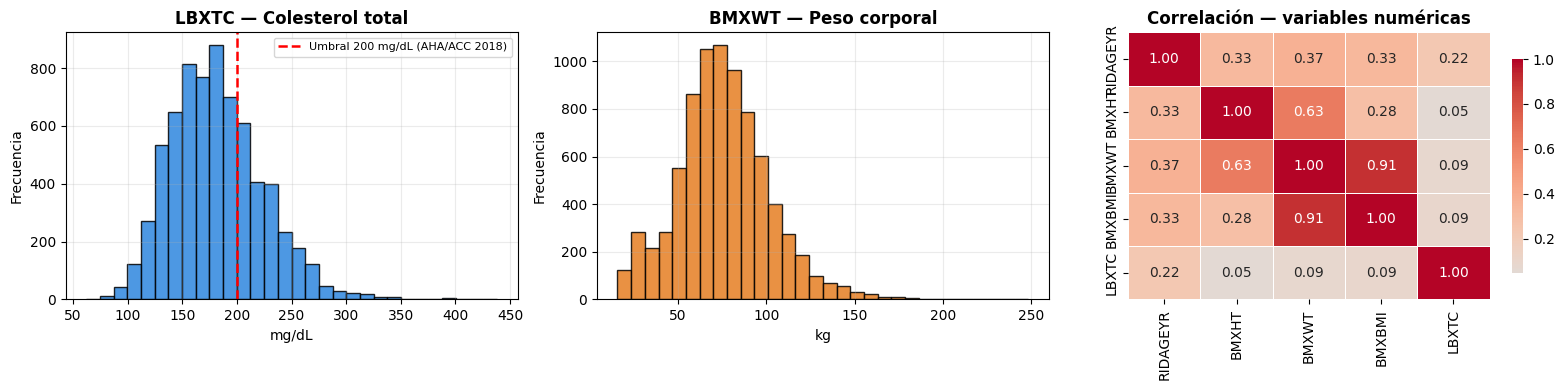

In [3]:
print('Dimensiones:', df.shape)
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())

print('\nResumen LBXTC (colesterol total, mg/dL):')
print(df['LBXTC'].describe())
print('\nResumen BMXWT (peso, kg):')
print(df['BMXWT'].describe())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribución colesterol con umbral clínico
axes[0].hist(df['LBXTC'].dropna(), bins=30, color='#2e86de', edgecolor='black', alpha=0.85)
axes[0].axvline(200, color='red', linestyle='--', linewidth=1.8, label='Umbral 200 mg/dL (AHA/ACC 2018)')
axes[0].set_title('LBXTC — Colesterol total', fontweight='bold')
axes[0].set_xlabel('mg/dL'); axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

# Distribución peso
axes[1].hist(df['BMXWT'].dropna(), bins=30, color='#e67e22', edgecolor='black', alpha=0.85)
axes[1].set_title('BMXWT — Peso corporal', fontweight='bold')
axes[1].set_xlabel('kg'); axes[1].set_ylabel('Frecuencia'); axes[1].grid(alpha=0.25)

# Heatmap de correlación
num_corr = df[['RIDAGEYR','BMXHT','BMXWT','BMXBMI','LBXTC']].corr()
sns.heatmap(num_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[2], linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[2].set_title('Correlación — variables numéricas', fontweight='bold')

plt.tight_layout(); plt.show()


## 3. Limpieza y codificación

Se convierten columnas numéricas, se imputan faltantes y se codifican variables categóricas. **Nota importante:** `BMXBMI` se imputa aquí para mantener el dataset íntegro, pero **será excluido de las features** en la siguiente sección — BMI = peso/altura² contiene directamente `BMXWT` (target de regresión), lo que constituiría **data leakage**.

In [4]:
# Asegurar que numéricas estén bien tipadas
numeric_cols = ['RIDAGEYR', 'BMXHT', 'BMXWT', 'BMXBMI', 'LBXTC']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputación simple
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Categóricas para codificar
cat_cols = ['RIAGENDR', 'RIDRETH1']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print('Shape después de codificar:', df_encoded.shape)
df_encoded.head()

Shape después de codificar: (8068, 11)


,SEQN,RIDAGEYR,BMXHT,BMXWT,BMXBMI,LBXTC,RIAGENDR_2.0,RIDRETH1_2.0,RIDRETH1_3.0,RIDRETH1_4.0,RIDRETH1_5.0
0,130378.0,43.0,179.5,86.9,27.0,264.0,False,False,False,False,True
1,130379.0,66.0,174.2,101.8,33.5,214.0,False,False,True,False,False
2,130380.0,44.0,152.9,69.4,29.7,187.0,True,True,False,False,False
3,130386.0,34.0,173.3,90.6,30.2,183.0,False,False,False,False,False
4,130387.0,68.0,155.9,103.5,42.6,203.0,True,False,True,False,False


## 4. Definición de features y targets

Se construyen `X`, `y_reg` y `y_clf`.

**⚠️ Data leakage evitado — `BMXBMI` excluido de features:**
BMI = peso(kg) / altura²(m²). Incluirlo para predecir `BMXWT` equivale a revelar la respuesta al modelo. Se excluye explícitamente.

**Umbral de clasificación:** `LBXTC ≥ 200 mg/dL` define colesterol 'límite alto' según las guías AHA/ACC 2018 para evaluación de riesgo cardiovascular *(Grundy et al., 2018; ref. TCHOL_L.pdf — documentación oficial del dataset)*.

In [5]:
# Features: excluir SEQN (id), BMXWT (target reg.), LBXTC (target clf.) y
# BMXBMI (data leakage: BMI = peso/altura², contiene directamente BMXWT)
feature_cols = [c for c in df_encoded.columns
                if c not in ['SEQN', 'BMXWT', 'LBXTC', 'BMXBMI']]

X = df_encoded[feature_cols].values.astype(np.float32)

# Target regresión: peso corporal
y_reg = df_encoded['BMXWT'].values.astype(np.float32).reshape(-1, 1)

# Target clasificación: 1 si colesterol alto (>=200 mg/dL), 0 si normal
y_clf = (df_encoded['LBXTC'] >= 200).astype(np.float32).values.reshape(-1, 1)

print('Features utilizadas:', feature_cols)
print('\nShape X:', X.shape)
print('Shape y_reg (BMXWT):', y_reg.shape)
print('Shape y_clf (LBXTC>=200):', y_clf.shape)
print('Balance clase colesterol alto:', round(float(y_clf.mean()), 3))
print('\nNota: BMXBMI excluido — contiene BMXWT (data leakage en regresión).')


Features utilizadas: ['RIDAGEYR', 'BMXHT', 'RIAGENDR_2.0', 'RIDRETH1_2.0', 'RIDRETH1_3.0', 'RIDRETH1_4.0', 'RIDRETH1_5.0']

Shape X: (8068, 7)
Shape y_reg (BMXWT): (8068, 1)
Shape y_clf (LBXTC>=200): (8068, 1)
Balance clase colesterol alto: 0.259

Nota: BMXBMI excluido — contiene BMXWT (data leakage en regresión).


## 5. Verificación de balance del target de clasificación

Se evalúa la proporción de clases. Si la clase minoritaria representa ≥ 40%, el dataset se considera balanceado. En caso contrario, se aplicará upsampling en train.

--- Prueba de balance (y_clf: LBXTC >= 200 mg/dL) ---
Clase 0 (colesterol normal <200):  5975 (74.06%)
Clase 1 (colesterol alto  >=200):  2093 (25.94%)
Razón desbalance (mayor/menor): 2.855
Conclusión: DESBALANCEADO — se aplicará upsampling en train.


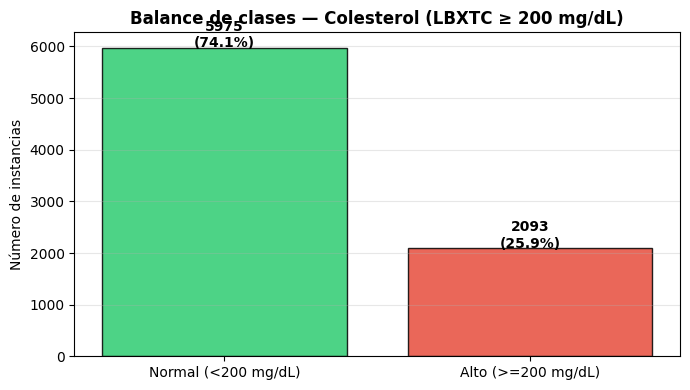

In [6]:
y_flat = y_clf.reshape(-1).astype(int)
class_counts = np.bincount(y_flat, minlength=2)
class_props = class_counts / class_counts.sum()
minority_prop = class_props.min()
imbalance_ratio = class_counts.max() / class_counts.min() if class_counts.min() > 0 else np.inf

print('--- Prueba de balance (y_clf: LBXTC >= 200 mg/dL) ---')
print(f'Clase 0 (colesterol normal <200):  {class_counts[0]} ({class_props[0]*100:.2f}%)')
print(f'Clase 1 (colesterol alto  >=200):  {class_counts[1]} ({class_props[1]*100:.2f}%)')
print(f'Razón desbalance (mayor/menor): {imbalance_ratio:.3f}')

if minority_prop >= 0.40:
    print('Conclusión: BALANCEADO — no requiere upsampling.')
else:
    print('Conclusión: DESBALANCEADO — se aplicará upsampling en train.')

# Visualización
fig, ax = plt.subplots(figsize=(7, 4))
labels = ['Normal (<200 mg/dL)', 'Alto (>=200 mg/dL)']
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(labels, class_counts, color=colors, edgecolor='black', alpha=0.85)
for bar, count, pct in zip(bars, class_counts, class_props * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Balance de clases — Colesterol (LBXTC ≥ 200 mg/dL)', fontweight='bold')
ax.set_ylabel('Número de instancias'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 6. Funciones utilitarias

Funciones reutilizables para split, balanceo y normalización:
- `split_numpy`: split aleatorio reproducible para regresión.
- `split_stratified_binary`: split manteniendo proporciones de clase.
- `upsample_minority`: upsampling con reemplazo (solo aplicar en train).
- `featureNormalize`: normalización Z-score; calcular en train, aplicar en test.

In [7]:
def split_numpy(X, y, test_ratio=0.2, seed=42):
    np.random.seed(seed)
    n_total = X.shape[0]
    n_test = int(test_ratio * n_total)
    n_train = n_total - n_test

    indices = np.random.permutation(n_total)
    train_idx = indices[:n_train]
    test_idx = indices[n_train:]

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]
    return X_train, y_train, X_test, y_test

def split_stratified_binary(X, y, test_ratio=0.2, seed=42):
    rng = np.random.default_rng(seed)
    y_flat = y.reshape(-1).astype(int)

    idx0 = np.where(y_flat == 0)[0]
    idx1 = np.where(y_flat == 1)[0]

    rng.shuffle(idx0)
    rng.shuffle(idx1)

    n0_test = int(test_ratio * len(idx0))
    n1_test = int(test_ratio * len(idx1))

    test_idx = np.concatenate([idx0[:n0_test], idx1[:n1_test]])
    train_idx = np.concatenate([idx0[n0_test:], idx1[n1_test:]])

    rng.shuffle(train_idx)
    rng.shuffle(test_idx)

    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

def upsample_minority(X, y, seed=42):
    rng = np.random.default_rng(seed)
    y_flat = y.reshape(-1).astype(int)

    idx0 = np.where(y_flat == 0)[0]
    idx1 = np.where(y_flat == 1)[0]

    if len(idx0) == len(idx1):
        return X, y

    if len(idx0) > len(idx1):
        idx_major, idx_minor = idx0, idx1
    else:
        idx_major, idx_minor = idx1, idx0

    idx_minor_upsampled = rng.choice(idx_minor, size=len(idx_major), replace=True)
    balanced_idx = np.concatenate([idx_major, idx_minor_upsampled])
    rng.shuffle(balanced_idx)

    return X[balanced_idx], y[balanced_idx]

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

## 7. Preparación para Regresión (predecir `BMXWT`)

Split 80/20, normalización Z-score y conversión a tensores. **Features:** edad, altura, género codificado, etnia codificada (sin BMXBMI).

In [8]:
Xr_train_np, yr_train_np, Xr_test_np, yr_test_np = split_numpy(X, y_reg, test_ratio=0.2, seed=42)

Xr_train_np, mu_r, sigma_r = featureNormalize(Xr_train_np)
Xr_test_np = (Xr_test_np - mu_r) / sigma_r

Xr_train = torch.from_numpy(Xr_train_np)
yr_train = torch.from_numpy(yr_train_np)
Xr_test = torch.from_numpy(Xr_test_np)
yr_test = torch.from_numpy(yr_test_np)

print('Regresión lista:')
print('Xr_train:', Xr_train.shape)
print('yr_train:', yr_train.shape)
print('Xr_test:', Xr_test.shape)
print('yr_test:', yr_test.shape)

Regresión lista:
Xr_train: torch.Size([6455, 7])
yr_train: torch.Size([6455, 1])
Xr_test: torch.Size([1613, 7])
yr_test: torch.Size([1613, 1])


## 8. Preparación para Clasificación (predecir `LBXTC ≥ 200 mg/dL`)

Split estratificado, upsampling **solo en train**, normalización Z-score y tensores. El test permanece sin modificar para reflejar la distribución real.

In [9]:
# Split estratificado para mantener proporciones por clase
Xc_train_np, yc_train_np, Xc_test_np, yc_test_np = split_stratified_binary(
    X, y_clf, test_ratio=0.2, seed=42
)

print('Antes de balancear (train):', float(yc_train_np.mean()))
print('Antes de balancear (test): ', float(yc_test_np.mean()))

# Balanceo SOLO en train (evitamos contaminar test)
Xc_train_np, yc_train_np = upsample_minority(Xc_train_np, yc_train_np, seed=42)

print('Después de balancear (train):', float(yc_train_np.mean()))

Xc_train_np, mu_c, sigma_c = featureNormalize(Xc_train_np)
Xc_test_np = (Xc_test_np - mu_c) / sigma_c

Xc_train = torch.from_numpy(Xc_train_np)
yc_train = torch.from_numpy(yc_train_np)
Xc_test = torch.from_numpy(Xc_test_np)
yc_test = torch.from_numpy(yc_test_np)

print('Clasificación lista:')
print('Xc_train:', Xc_train.shape)
print('yc_train:', yc_train.shape)
print('Xc_test:', Xc_test.shape)
print('yc_test:', yc_test.shape)
print('Proporción clase 1 en train balanceado:', float(yc_train.mean()))
print('Proporción clase 1 en test (real):', float(yc_test.mean()))

Antes de balancear (train): 0.2594887614250183
Antes de balancear (test):  0.25914445519447327
Después de balancear (train): 0.5
Clasificación lista:
Xc_train: torch.Size([9560, 7])
yc_train: torch.Size([9560, 1])
Xc_test: torch.Size([1613, 7])
yc_test: torch.Size([1613, 1])
Proporción clase 1 en train balanceado: 0.5
Proporción clase 1 en test (real): 0.25914445519447327


## 9. Tabla resumen de variables

| Variable | Tipo | Descripción | Tratamiento aplicado |
|---|---|---|---|
| `SEQN` | Identificador | Número de secuencia del participante | Excluido |
| `RIDAGEYR` | Numérica | Edad en años (screening) | Imputación mediana |
| `BMXHT` | Numérica | Altura de pie (cm) | Imputación mediana |
| `BMXWT` | Numérica **(target regresión)** | Peso corporal (kg) | Imputación mediana; target de regresión |
| `BMXBMI` | Numérica — **excluida de features** | IMC = peso/altura² | Imputada en limpieza; **excluida por data leakage** |
| `LBXTC` | Numérica **(target clasificación)** | Colesterol total (mg/dL) | Imputación mediana; binarizada: 1 si ≥200 mg/dL |
| `RIAGENDR` | Categórica (1=M, 2=F) | Género | Imputación moda + OHE `drop_first` |
| `RIDRETH1` | Categórica (1–5) | Raza/origen hispano | Imputación moda + OHE `drop_first` |

**Decisiones clave:**
- `BMXBMI` excluido: BMI depende matemáticamente de `BMXWT` → data leakage severo en regresión.
- Umbral `LBXTC ≥ 200 mg/dL` basado en guías AHA/ACC 2018 *(Grundy et al., 2018)*.
- Join inner por `SEQN`: solo participantes con datos en las tres fuentes.
- Split estratificado en clasificación + upsampling solo en train.
- Normalización Z-score sin leakage: µ y σ del train, aplicados a test.
